# Task 5: Visualization and Reporting

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load the cleaned dataset
df = pd.read_csv("../data/Amazon_Cleaned.csv")

# Remove leading/trailing spaces from column names
df.columns = df.columns.str.strip()

# Display the first five rows
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 25 columns):
 #   Column                                 Non-Null Count  Dtype 
---  ------                                 --------------  ----- 
 0   Timestamp                              800 non-null    object
 1   age                                    800 non-null    int64 
 2   Gender                                 800 non-null    object
 3   Purchase_Frequency                     800 non-null    object
 4   Purchase_Categories                    800 non-null    object
 5   Personalized_Recommendation_Frequency  800 non-null    object
 6   Browsing_Frequency                     800 non-null    object
 7   Product_Search_Method                  800 non-null    object
 8   Search_Result_Exploration              800 non-null    object
 9   Customer_Reviews_Importance            800 non-null    int64 
 10  Add_to_Cart_Browsing                   800 non-null    object
 11  Cart_Completion_Fre

In [3]:
visualization_columns = [
    "Purchase_Categories",
    "Browsing_Frequency",
    "Shopping_Satisfaction",
    "Recommendation_Helpfulness"
]

df[visualization_columns].head()

,Purchase_Categories,Browsing_Frequency,Shopping_Satisfaction,Recommendation_Helpfulness
0,Clothing and Fashion,Multiple Times A Day,4,Sometimes
1,Groceries and Gourmet Food;Beauty and Personal...,Rarely,5,Sometimes
2,Groceries and Gourmet Food;Beauty and Personal...,Few Times A Week,3,No
3,Beauty and Personal Care;Clothing and Fashion;...,Few Times A Month,2,Yes
4,Beauty and Personal Care;Clothing and Fashion;...,Few Times A Month,2,Yes


## Purchase Category Distribution
**Purpose:** Identify the most frequently purchased product categories to understand customer purchasing preferences.

In [6]:
# Split multiple categories into separate rows

purchase_categories = (
    df["Purchase_Categories"]
    .str.split(";")
    .explode()
    .str.strip()
)

purchase_category_counts = purchase_categories.value_counts()

purchase_category_counts

Purchase_Categories
Clothing and Fashion          450
others                        412
Home and Kitchen              391
Beauty and Personal Care      383
Groceries and Gourmet Food    369
Name: count, dtype: int64

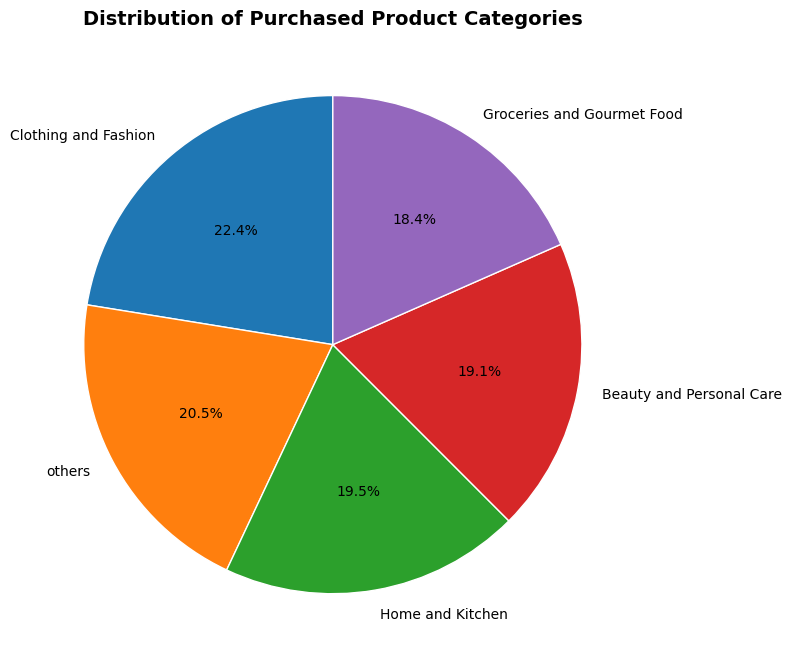

In [18]:
# Visualization 

plt.figure(figsize=(8,8))

plt.pie(
    purchase_category_counts,
    labels=purchase_category_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"edgecolor":"white"}
)

plt.title("Distribution of Purchased Product Categories",
          fontsize=14,
          weight="bold")

plt.tight_layout()
plt.show()

**Insight:**
- Clothing and Fashion is the most frequently purchased product category, with 450 purchases, making it the highest-demand category among the surveyed customers.
- The 'Others' category ranks second with 412 purchases, indicating that a considerable number of purchases belong to product categories outside the four primary categories.
- Home and Kitchen (391) and Beauty and Personal Care (383) also show strong customer demand, with purchase counts close to one another.
- Groceries and Gourmet Food recorded the lowest purchase count (369) among the major categories, although the difference compared to the other categories is relatively small.
- Overall, customer purchases are distributed across multiple product categories, suggesting diverse shopping preferences rather than a strong dependence on a single category.

## Browsing Frequency Distribution
**Purpose:** Analyze how frequently customers browse Amazon to understand overall customer engagement with the platform.

In [8]:
# Count the browsing frequency of customers
browsing_frequency_counts = (
    df["Browsing_Frequency"]
    .value_counts()
)

browsing_frequency_counts

Browsing_Frequency
Rarely                  231
Few Times A Month       200
Few Times A Week        186
Multiple Times A Day    183
Name: count, dtype: int64

In [12]:
# Visualization 
browsing_order = [
    "Rarely",
    "Few Times A Month",
    "Few Times A Week",
    "Multiple Times A Day"
]

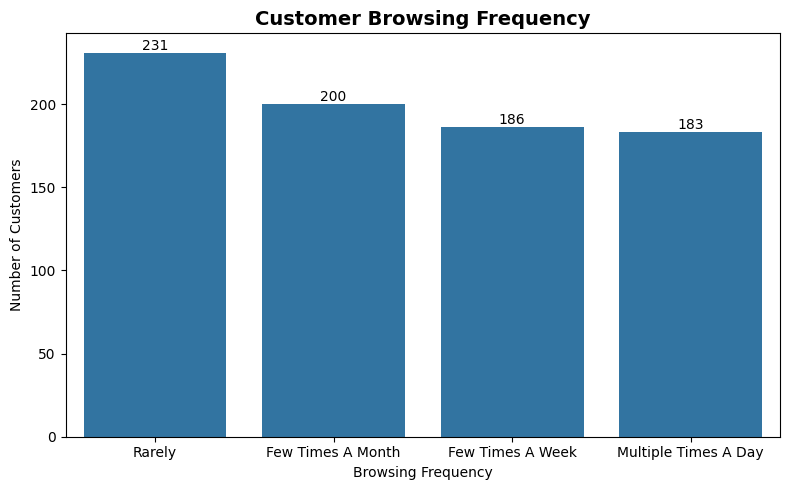

In [13]:
# Visualization 
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df,
    x="Browsing_Frequency",
    order=browsing_order
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Customer Browsing Frequency", fontsize=14, weight="bold")
plt.xlabel("Browsing Frequency")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

**Insight:**
- Rarely is the most common browsing frequency, with 231 customers, indicating that a large proportion of customers do not visit Amazon frequently.
- Few Times A Month is the second most common browsing pattern (200 customers), suggesting that many customers browse the platform on a periodic rather than daily basis.
- Few Times A Week (186) and Multiple Times A Day (183) have similar customer counts, indicating a comparable number of moderately active and highly active users.
- The differences between the four browsing frequency groups are relatively small, showing that customer engagement is distributed across different browsing habits rather than being concentrated in a single group.
- Overall, the dataset represents a balanced mix of occasional and frequent shoppers, providing a diverse view of customer browsing behavior.

## Shopping Satisfaction Distribution
**Purpose:** Analyze the distribution of customer shopping satisfaction ratings to understand the overall satisfaction level of customers.

In [14]:
# Count customer satisfaction ratings
satisfaction_counts = (
    df["Shopping_Satisfaction"]
    .value_counts()
    .sort_index()
)

satisfaction_counts

Shopping_Satisfaction
1    152
2    168
3    160
4    158
5    162
Name: count, dtype: int64

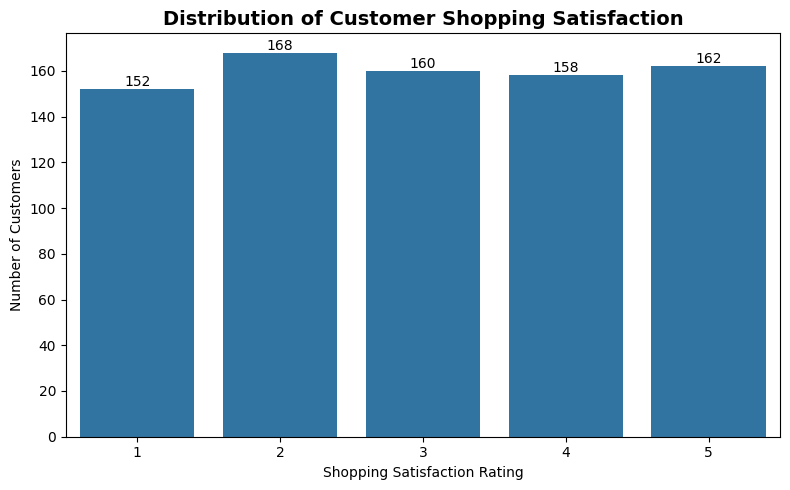

In [15]:
# Visualization

plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df,
    x="Shopping_Satisfaction",
    order=sorted(df["Shopping_Satisfaction"].unique())
)

# Add value labels
for container in ax.containers:
    ax.bar_label(container)

plt.title("Distribution of Customer Shopping Satisfaction", fontsize=14, weight="bold")
plt.xlabel("Shopping Satisfaction Rating")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

**Insight:**
- Customer shopping satisfaction ratings are fairly evenly distributed across all five rating levels, indicating a balanced mix of positive, neutral, and negative experiences.
- Rating 2 is the most common satisfaction level, with 168 customers, while Rating 1 is the least common, with 152 customers.
- Higher satisfaction ratings (4 and 5) account for 320 responses, whereas lower satisfaction ratings (1 and 2) account for 320 responses, showing an almost identical distribution between satisfied and dissatisfied customers.
- The balanced distribution suggests that customer experiences vary considerably, with no single satisfaction level dominating the dataset.
- Overall, the findings indicate that there is room for improvement in customer satisfaction, as highly satisfied customers do not substantially outnumber dissatisfied customers.

## Recommendation Helpfulness vs Shopping Satisfaction
**Purpose:** Visualize the average shopping satisfaction across different levels of recommendation helpfulness to assess whether customers who find recommendations more useful report higher satisfaction.

In [16]:
# Calculate average shopping satisfaction for each recommendation helpfulness category
recommendation_satisfaction = (
    df.groupby("Recommendation_Helpfulness")["Shopping_Satisfaction"]
      .agg(["mean", "count"])
      .reindex(["Yes", "Sometimes", "No"])
)

recommendation_satisfaction

,mean,count
Recommendation_Helpfulness,,
Yes,3.040741,270
Sometimes,2.955224,268
No,3.041985,262


In [19]:
# Create a contingency table
recommendation_heatmap = pd.crosstab(
    df["Recommendation_Helpfulness"],
    df["Shopping_Satisfaction"]
)

recommendation_heatmap

Shopping_Satisfaction,1,2,3,4,5
Recommendation_Helpfulness,,,,,
No,49,52,52,57,52
Sometimes,57,55,52,51,53
Yes,46,61,56,50,57


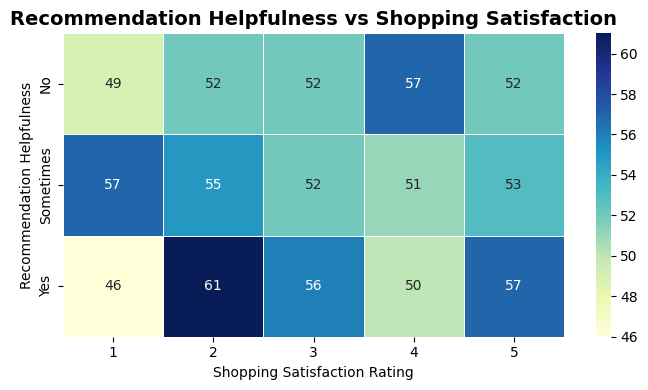

In [20]:
# Visualization

plt.figure(figsize=(7,4))

sns.heatmap(
    recommendation_heatmap,
    annot=True,
    fmt="d",
    cmap="YlGnBu",
    linewidths=0.5
)

plt.title(
    "Recommendation Helpfulness vs Shopping Satisfaction",
    fontsize=14,
    weight="bold"
)

plt.xlabel("Shopping Satisfaction Rating")
plt.ylabel("Recommendation Helpfulness")

plt.tight_layout()
plt.show()

**Insights:**
- Customer satisfaction ratings are fairly evenly distributed across all recommendation helpfulness categories, with no strong concentration in any particular satisfaction level.
- Customers who reported that recommendations were helpful ("Yes") recorded the highest count for Shopping Satisfaction Rating 2 (61 customers), while customers who selected "No" showed the highest count for Rating 4 (57 customers).
- The "Sometimes" group also exhibits a balanced distribution of satisfaction ratings, with customer counts ranging from 51 to 57, indicating no dominant satisfaction pattern.
- The similarity in customer counts across all cells suggests that recommendation helpfulness does not strongly influence shopping satisfaction.
- Overall, the heatmap visually reinforces the statistical findings from Task 4, where the Chi-Square Test concluded that there is no statistically significant relationship between recommendation helpfulness and shopping satisfaction.

## Key Insights
- Clothing and Fashion was the most frequently purchased product category, followed closely by Others, Home and Kitchen, and Beauty and Personal Care.
- Customer browsing behavior was distributed across all browsing frequencies, with Rarely being the most common browsing pattern.
- Shopping satisfaction ratings were nearly evenly distributed across all five rating levels, indicating varied customer experiences.
- Recommendation helpfulness showed minimal variation in average shopping satisfaction, reinforcing the conclusion that it is not a significant driver of customer satisfaction in this dataset.

## Business Recommendations
- Continue strengthening the Clothing and Fashion category through inventory optimization and targeted promotional campaigns.
- Refine the "Others" category by introducing more specific product classifications to improve customer insights and recommendation accuracy.
- Increase customer engagement through personalized marketing campaigns aimed at customers who browse infrequently.
- Prioritize improvements in product quality, delivery efficiency, pricing, and customer support, as these factors are likely to have a greater influence on customer satisfaction than recommendation helpfulness alone.
- Continuously refine the recommendation engine using customer browsing and purchase behavior to improve recommendation relevance, while recognizing that recommendation quality should complement—not replace—core service improvements.